In [1]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from libra_py import units
%matplotlib inline

In [2]:
def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level = 0.95, r2_min = 0.7):

    # Create a 1x1 grid of subplots with a more square-like figure size
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)

    # Loop through each method
    for c, method in enumerate(['FSSH2']):
        taus = []
        fit_function = fitting_for_method[method]
    
        for icond in iconds:
            try:
                with h5py.File(f'{method}0_icond_{icond}/mem_data.hdf', 'r') as F:
                    sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                    md_time = np.array(F['time/data'][:]) * units.au2fs
            except FileNotFoundError:
                print(f"File not found: {method}_icond_{icond}/mem_data.hdf, skipping.")
                continue

            popt, pcov = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
            tau = popt
            residuals = sh_pop - fit_function(md_time, *popt)
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
            r_squared = 1.0 - (ss_res / ss_tot)

            print(f"icond: {icond}, r_squared: {r_squared}, tau: {tau}")  # Print r_squared for each icond

            # Only append tau and plot if r_squared is greater than 0.1        
            if r_squared > r2_min:
                ax.plot(md_time, sh_pop, color='blue', linewidth=2.0)  # Line color is black
                taus.append(tau)
                print(F"plotting this batch, the fitted tau is {tau}")
            else:
                ax.plot(md_time, sh_pop, color='grey', linewidth=2.0) 

        taus = np.array(taus)
        if len(taus) > 0:  # Proceed only if there are valid taus
            ave_tau = np.average(taus)
            s = np.std(taus)            
            N = taus.shape[0]
            #Z = 1.96 - naive value
            Z = stdtrit(N-1, conf_level) # better approach
            print(F"Z = {Z}")
            error_bar = Z * s / np.sqrt(N) 
        
            # Convert timescale to picoseconds (ps)
            ave_tau_ps = ave_tau / 1000
            error_bar_ps = error_bar / 1000
        
            print(f'The timescales for method {method}: \n {ave_tau_ps}+-{error_bar_ps} ps, averaged over {len(taus)} samples')

            ax.plot(md_time, fit_function(md_time, ave_tau - error_bar), ls='--', color="red", linewidth=2.0)
        
            # Increase the linewidth of the solid red line
            ax.plot(md_time, fit_function(md_time, ave_tau), ls='-', color="red", label=f"{method}: {ave_tau_ps:.1f} ± {error_bar_ps:.1f} ps \n \
$R^2$: {r2_min} confidence: {conf_level*100}%", linewidth=4)
        
            ax.plot(md_time, fit_function(md_time, ave_tau + error_bar), ls='--', color="red", linewidth=2.0)
            ax.fill_between(md_time, fit_function(md_time, ave_tau - error_bar), fit_function(md_time, ave_tau + error_bar), color='red', alpha=0.1, linewidth=2.0)

        # Set the same plot settings as before
        ax.tick_params(axis='x', labelsize=24, width=2.5, length=10)
        ax.tick_params(axis='y', labelsize=24, width=2.5, length=10)
        ax.set_xlim(left=-500, right=4001)
        ax.set_ylim(bottom=-0.001, top=0.021)
        ax.set_facecolor('white')

        for spine in ax.spines.values():
            spine.set_linewidth(2.5)

        ax.set_title(F'{figuretitle}', fontsize=26, pad=20, x=0.45)
        ax.set_xlabel('Time, fs', fontsize=26)
        ax.set_ylabel('Population', fontsize=26)

        ax.legend(fontsize=20, loc='upper left')
        fig.patch.set_facecolor('white')
        ax.set_xticks(np.arange(0, 3001, 1000))
        ax.set_ylim(0, 0.5)
        ax.set_xlim(0, 3000)
        yticks = np.linspace(0, 0.5, 5)
        #yticklabels = [f"{y:.5f}" for y in yticks]
        
        yticklabels = [f"{y:.3f}" for y in yticks]

# ===== 关键：要把它们设置到图上 =====
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels, fontsize=24)
        plt.tight_layout()
        plt.savefig(F'{figurename}', dpi=600)
        plt.show()

In [3]:
# Fitting functions

def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

icond: 1, r_squared: 0.981217355194853, tau: [3672.41407315]
plotting this batch, the fitted tau is [3672.41407315]
icond: 101, r_squared: 0.9964750401879808, tau: [3635.60911362]
plotting this batch, the fitted tau is [3635.60911362]
icond: 201, r_squared: 0.9905003681564915, tau: [3664.24074947]
plotting this batch, the fitted tau is [3664.24074947]
icond: 301, r_squared: 0.9951431310741291, tau: [3666.05863781]
plotting this batch, the fitted tau is [3666.05863781]
icond: 401, r_squared: 0.9887789702839818, tau: [3652.1290606]
plotting this batch, the fitted tau is [3652.1290606]
icond: 501, r_squared: 0.9874790436141395, tau: [3755.40430996]
plotting this batch, the fitted tau is [3755.40430996]
icond: 601, r_squared: 0.9876221528724385, tau: [3586.39942637]
plotting this batch, the fitted tau is [3586.39942637]
icond: 701, r_squared: 0.9854096172291514, tau: [3868.75853728]
plotting this batch, the fitted tau is [3868.75853728]
icond: 801, r_squared: 0.9821238528950385, tau: [3612

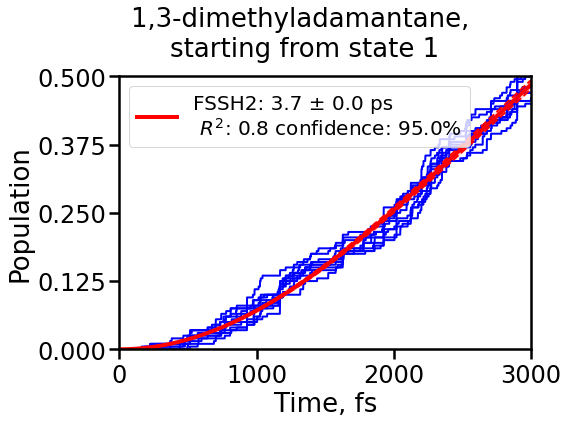

In [4]:
methods = ["FSSH2"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'FSSH2': gau_func } 
figuretitle = "1,3-dimethyladamantane, \nstarting from state 1"
figurename = "FSSH2-gau.png"



fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level = 0.95, r2_min = 0.8)

In [5]:
def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level = 0.95, r2_min = 0.7):

    # Create a 1x1 grid of subplots with a more square-like figure size
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)

    # Loop through each method
    for c, method in enumerate(['FSSH']):
        taus = []
        fit_function = fitting_for_method[method]
    
        for icond in iconds:
            try:
                with h5py.File(f'{method}_icond_{icond}/mem_data.hdf', 'r') as F:
                    sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                    md_time = np.array(F['time/data'][:]) * units.au2fs
            except FileNotFoundError:
                print(f"File not found: {method}_icond_{icond}/mem_data.hdf, skipping.")
                continue

            popt, pcov = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
            tau = popt
            residuals = sh_pop - fit_function(md_time, *popt)
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
            r_squared = 1.0 - (ss_res / ss_tot)

            print(f"icond: {icond}, r_squared: {r_squared}, tau: {tau}")  # Print r_squared for each icond

            # Only append tau and plot if r_squared is greater than 0.1        
            if r_squared > r2_min:
                ax.plot(md_time, sh_pop, color='blue', linewidth=2.0)  # Line color is black
                taus.append(tau)
                print(F"plotting this batch, the fitted tau is {tau}")
            else:
                ax.plot(md_time, sh_pop, color='grey', linewidth=2.0) 

        taus = np.array(taus)
        if len(taus) > 0:  # Proceed only if there are valid taus
            ave_tau = np.average(taus)
            s = np.std(taus)            
            N = taus.shape[0]
            #Z = 1.96 - naive value
            Z = stdtrit(N-1, conf_level) # better approach
            print(F"Z = {Z}")
            error_bar = Z * s / np.sqrt(N) 
        
            # Convert timescale to picoseconds (ps)
            ave_tau_ps = ave_tau / 1000
            error_bar_ps = error_bar / 1000
        
            print(f'The timescales for method {method}: \n {ave_tau_ps}+-{error_bar_ps} ps, averaged over {len(taus)} samples')

            ax.plot(md_time, fit_function(md_time, ave_tau - error_bar), ls='--', color="red", linewidth=2.0)
        
            # Increase the linewidth of the solid red line
            ax.plot(md_time, fit_function(md_time, ave_tau), ls='-', color="red", label=f"{method}: {ave_tau_ps:.1f} ± {error_bar_ps:.1f} ps \n \
$R^2$: {r2_min} confidence: {conf_level*100}%", linewidth=4)
        
            ax.plot(md_time, fit_function(md_time, ave_tau + error_bar), ls='--', color="red", linewidth=2.0)
            ax.fill_between(md_time, fit_function(md_time, ave_tau - error_bar), fit_function(md_time, ave_tau + error_bar), color='red', alpha=0.1, linewidth=2.0)

        # Set the same plot settings as before
        ax.tick_params(axis='x', labelsize=24, width=2.5, length=10)
        ax.tick_params(axis='y', labelsize=24, width=2.5, length=10)
        ax.set_xlim(left=-500, right=4001)
        ax.set_ylim(bottom=-0.001, top=0.021)
        ax.set_facecolor('white')

        for spine in ax.spines.values():
            spine.set_linewidth(2.5)

        ax.set_title(F'{figuretitle}', fontsize=26, pad=20, x=0.45)
        ax.set_xlabel('Time, fs', fontsize=26)
        ax.set_ylabel('Population', fontsize=26)

        ax.legend(fontsize=20, loc='upper left')
        fig.patch.set_facecolor('white')
        ax.set_xticks(np.arange(0, 6001, 2000))
        ax.set_ylim(0, 1)

        plt.tight_layout()
        plt.savefig(F'{figurename}', dpi=600)
        plt.show()

icond: 1, r_squared: 0.9603405792564398, tau: [6813.05728754]
plotting this batch, the fitted tau is [6813.05728754]
icond: 101, r_squared: 0.9808166492644742, tau: [6356.14391536]
plotting this batch, the fitted tau is [6356.14391536]
icond: 201, r_squared: 0.9680670963588454, tau: [6461.58947148]
plotting this batch, the fitted tau is [6461.58947148]
icond: 301, r_squared: 0.9713301288599635, tau: [6189.34920447]
plotting this batch, the fitted tau is [6189.34920447]
icond: 401, r_squared: 0.9544102188714556, tau: [6411.09207788]
plotting this batch, the fitted tau is [6411.09207788]
icond: 501, r_squared: 0.952023905734525, tau: [6170.95524969]
plotting this batch, the fitted tau is [6170.95524969]
icond: 601, r_squared: 0.9340439472534093, tau: [6177.22654163]
plotting this batch, the fitted tau is [6177.22654163]
icond: 701, r_squared: 0.9637804346046337, tau: [6548.61066497]
plotting this batch, the fitted tau is [6548.61066497]
icond: 801, r_squared: 0.9498810692423061, tau: [62

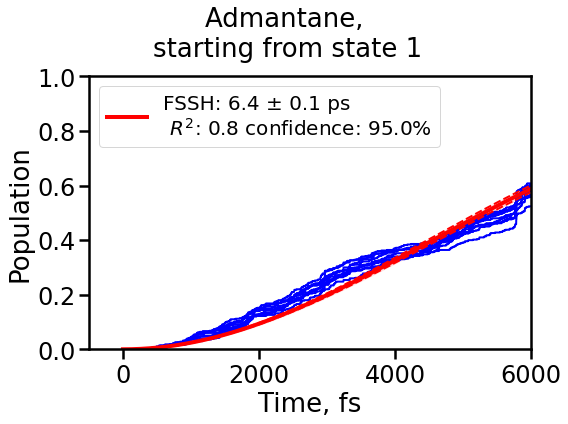

In [6]:
methods = ["FSSH"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'FSSH': gau_func } 
figuretitle = "Admantane, \nstarting from state 1"
figurename = "FSSH000gau.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level = 0.95, r2_min = 0.8)

Path: FSSH_icond_, icond: 1, r_squared: 0.9603405792564398, tau: [6813.05728754]
Path: FSSH_icond_, icond: 101, r_squared: 0.9808166492644742, tau: [6356.14391536]
Path: FSSH_icond_, icond: 201, r_squared: 0.9680670963588454, tau: [6461.58947148]
Path: FSSH_icond_, icond: 301, r_squared: 0.9713301288599635, tau: [6189.34920447]
Path: FSSH_icond_, icond: 401, r_squared: 0.9544102188714556, tau: [6411.09207788]
Path: FSSH_icond_, icond: 501, r_squared: 0.952023905734525, tau: [6170.95524969]
Path: FSSH_icond_, icond: 601, r_squared: 0.9340439472534093, tau: [6177.22654163]
Path: FSSH_icond_, icond: 701, r_squared: 0.9637804346046337, tau: [6548.61066497]
Path: FSSH_icond_, icond: 801, r_squared: 0.9498810692423061, tau: [6229.12230645]
Path: FSSH_icond_, icond: 901, r_squared: 0.9802469389841775, tau: [6345.52843858]
FSSH (FSSH_icond_): 6.37 ± 0.11 ps (N=10)
Path: FSSH0_icond_, icond: 1, r_squared: 0.992184566448746, tau: [3474.80122405]
Path: FSSH0_icond_, icond: 101, r_squared: 0.98882

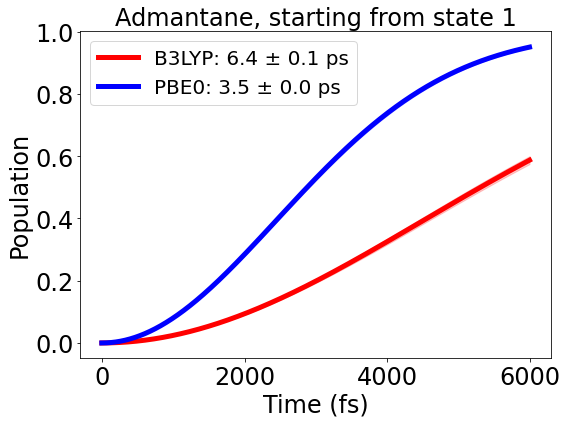

In [18]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from libra_py import units

def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level=0.95, r2_min=0.7):
    # 创建画布
    fig, ax = plt.subplots(figsize=(8, 6))

    colors = ['red', 'blue']  # 不同路径的颜色
    prefixes = ["FSSH_icond_", "FSSH0_icond_"]  # 两种路径格式
    pre_name = ["B3LYP", "PBE0"]  # 两种路径格式
    for method in methods:
        for i, prefix in enumerate(prefixes):
            taus = []
            fit_function = fitting_for_method[method]

            for icond in iconds:
                filepath = f"{prefix}{icond}/mem_data.hdf"
                try:
                    # 读取数据
                    with h5py.File(filepath, 'r') as F:
                        sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                        md_time = np.array(F['time/data'][:]) * units.au2fs
                except FileNotFoundError:
                    print(f"File not found: {filepath}, skipping.")
                    continue

                # 数据拟合
                popt, _ = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
                residuals = sh_pop - fit_function(md_time, *popt)
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
                r_squared = 1.0 - (ss_res / ss_tot)

                # 筛选符合R^2阈值的数据
                if r_squared > r2_min:
                    taus.append(popt)
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, tau: {popt}")
                else:
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, skipped.")

            # 统计结果并绘制拟合曲线
            if taus:
                taus = np.array(taus)
                ave_tau = np.mean(taus)
                s = np.std(taus)
                N = taus.shape[0]
                Z = stdtrit(N - 1, conf_level)
                error_bar = Z * s / np.sqrt(N)

                # 时间尺度转换为皮秒
                ave_tau_ps = ave_tau / 1000
                error_bar_ps = error_bar / 1000
                print(f'{method} ({prefix}): {ave_tau_ps:.2f} ± {error_bar_ps:.2f} ps (N={N})')

                # 绘制拟合曲线
                ax.plot(md_time, fit_function(md_time, ave_tau), color=colors[i], label=f"{pre_name[i]}: {ave_tau_ps:.1f} ± {error_bar_ps:.1f} ps", linewidth=5)
                ax.fill_between(md_time, 
                                fit_function(md_time, ave_tau - error_bar), 
                                fit_function(md_time, ave_tau + error_bar), 
                                color=colors[i], alpha=0.2)

    # 图表设置
    ax.set_title(figuretitle, fontsize=24)
    ax.set_xlabel('Time (fs)', fontsize=24)
    ax.set_ylabel('Population', fontsize=24)
    ax.tick_params(axis='both', labelsize=24)
    ax.legend(fontsize=20)
    plt.tight_layout()
    plt.savefig(figurename, dpi=300)
    plt.show()

# 定义拟合函数
def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

# 参数设置与调用
methods = ["FSSH"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'FSSH': gau_func}
figuretitle = "Admantane, starting from state 1"
figurename = "FSSH_combined_fit.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level=0.95, r2_min=0.8)


Path: FSSH_icond_, icond: 1, r_squared: 0.9603405792564398, tau: [6813.05728754]
Path: FSSH_icond_, icond: 101, r_squared: 0.9808166492644742, tau: [6356.14391536]
Path: FSSH_icond_, icond: 201, r_squared: 0.9680670963588454, tau: [6461.58947148]
Path: FSSH_icond_, icond: 301, r_squared: 0.9713301288599635, tau: [6189.34920447]
Path: FSSH_icond_, icond: 401, r_squared: 0.9544102188714556, tau: [6411.09207788]
Path: FSSH_icond_, icond: 501, r_squared: 0.952023905734525, tau: [6170.95524969]
Path: FSSH_icond_, icond: 601, r_squared: 0.9340439472534093, tau: [6177.22654163]
Path: FSSH_icond_, icond: 701, r_squared: 0.9637804346046337, tau: [6548.61066497]
Path: FSSH_icond_, icond: 801, r_squared: 0.9498810692423061, tau: [6229.12230645]
Path: FSSH_icond_, icond: 901, r_squared: 0.9802469389841775, tau: [6345.52843858]
FSSH (FSSH_icond_): 6.37 ± 0.11 ps (N=10)
Path: FSSH0_icond_, icond: 1, r_squared: 0.992184566448746, tau: [3474.80122405]
Path: FSSH0_icond_, icond: 101, r_squared: 0.98882

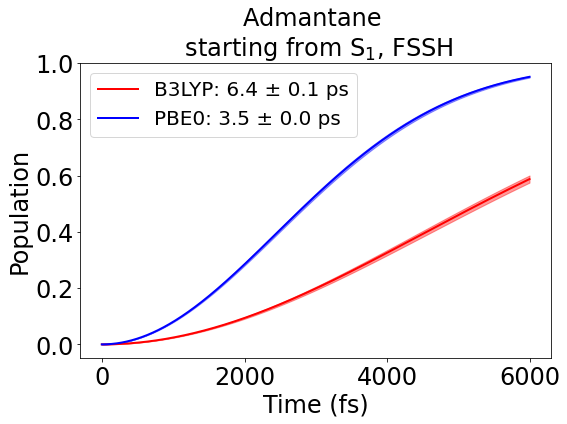

In [26]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from libra_py import units

def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level=0.95, r2_min=0.7):
    # 创建画布
    fig, ax = plt.subplots(figsize=(8, 6))

    colors = ['red', 'blue']  # 不同路径的颜色
    prefixes = ["FSSH_icond_", "FSSH0_icond_"]  # 两种路径格式
    pre_name = ["B3LYP", "PBE0"]  # 两种路径格式
    for method in methods:
        for i, prefix in enumerate(prefixes):
            taus = []
            fit_function = fitting_for_method[method]

            for icond in iconds:
                filepath = f"{prefix}{icond}/mem_data.hdf"
                try:
                    # 读取数据
                    with h5py.File(filepath, 'r') as F:
                        sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                        md_time = np.array(F['time/data'][:]) * units.au2fs
                except FileNotFoundError:
                    print(f"File not found: {filepath}, skipping.")
                    continue

                # 数据拟合
                popt, _ = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
                residuals = sh_pop - fit_function(md_time, *popt)
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
                r_squared = 1.0 - (ss_res / ss_tot)

                # 筛选符合R^2阈值的数据
                if r_squared > r2_min:
                    taus.append(popt)
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, tau: {popt}")
                else:
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, skipped.")

            # 统计结果并绘制拟合曲线
            if taus:
                taus = np.array(taus)
                ave_tau = np.mean(taus)
                s = np.std(taus)
                N = taus.shape[0]
                Z = stdtrit(N - 1, conf_level)
                error_bar = Z * s / np.sqrt(N)

                # 时间尺度转换为皮秒
                ave_tau_ps = ave_tau / 1000
                error_bar_ps = error_bar / 1000
                print(f'{method} ({prefix}): {ave_tau_ps:.2f} ± {error_bar_ps:.2f} ps (N={N})')

                # 绘制拟合曲线（加粗线条）
                ax.plot(md_time, fit_function(md_time, ave_tau), color=colors[i], label=f"{pre_name[i]}: {ave_tau_ps:.1f} ± {error_bar_ps:.1f} ps", linewidth=2)  # 加粗线条
                # 绘制误差条（加深透明度和加粗）
                ax.fill_between(md_time, 
                                fit_function(md_time, ave_tau - error_bar), 
                                fit_function(md_time, ave_tau + error_bar), 
                                color=colors[i], alpha=0.4)  # 提高透明度

    # 图表设置
    ax.set_title(figuretitle, fontsize=24)
    ax.set_xlabel('Time (fs)', fontsize=24)
    ax.set_ylabel('Population', fontsize=24)
    ax.tick_params(axis='both', labelsize=24)
    ax.legend(fontsize=20)
    plt.tight_layout()
    plt.savefig(figurename, dpi=300)
    plt.show()

# 定义拟合函数
def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

# 参数设置与调用
methods = ["FSSH"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'FSSH': gau_func}
figuretitle = "Admantane \n starting from S$_1$, FSSH"
figurename = "FSSH_combined_fit.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level=0.95, r2_min=0.8)


Path: FSSH_icond_, icond: 1, r_squared: 0.9603405792564398, tau: [6813.05728754]
Path: FSSH_icond_, icond: 101, r_squared: 0.9808166492644742, tau: [6356.14391536]
Path: FSSH_icond_, icond: 201, r_squared: 0.9680670963588454, tau: [6461.58947148]
Path: FSSH_icond_, icond: 301, r_squared: 0.9713301288599635, tau: [6189.34920447]
Path: FSSH_icond_, icond: 401, r_squared: 0.9544102188714556, tau: [6411.09207788]
Path: FSSH_icond_, icond: 501, r_squared: 0.952023905734525, tau: [6170.95524969]
Path: FSSH_icond_, icond: 601, r_squared: 0.9340439472534093, tau: [6177.22654163]
Path: FSSH_icond_, icond: 701, r_squared: 0.9637804346046337, tau: [6548.61066497]
Path: FSSH_icond_, icond: 801, r_squared: 0.9498810692423061, tau: [6229.12230645]
Path: FSSH_icond_, icond: 901, r_squared: 0.9802469389841775, tau: [6345.52843858]
FSSH (FSSH_icond_): 6.37 ± 0.11 ps (N=10)
Path: FSSH0_icond_, icond: 1, r_squared: 0.992184566448746, tau: [3474.80122405]
Path: FSSH0_icond_, icond: 101, r_squared: 0.98882

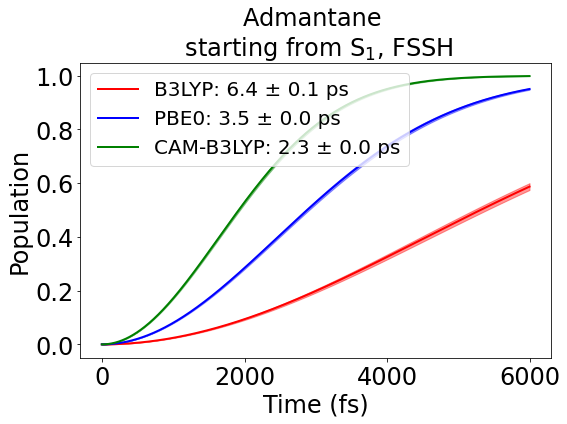

In [28]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from libra_py import units

def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level=0.95, r2_min=0.7):
    # 创建画布
    fig, ax = plt.subplots(figsize=(8, 6))

    colors = ['red', 'blue', 'green']  # 不同路径的颜色
    prefixes = ["FSSH_icond_", "FSSH0_icond_", "FSSH1_icond_"]  # 三种路径格式
    pre_name = ["B3LYP", "PBE0", "CAM-B3LYP"]  # 三种路径对应名称
    for method in methods:
        for i, prefix in enumerate(prefixes):
            taus = []
            fit_function = fitting_for_method[method]

            for icond in iconds:
                filepath = f"{prefix}{icond}/mem_data.hdf"
                try:
                    # 读取数据
                    with h5py.File(filepath, 'r') as F:
                        sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                        md_time = np.array(F['time/data'][:]) * units.au2fs
                except FileNotFoundError:
                    print(f"File not found: {filepath}, skipping.")
                    continue

                # 数据拟合
                popt, _ = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
                residuals = sh_pop - fit_function(md_time, *popt)
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
                r_squared = 1.0 - (ss_res / ss_tot)

                # 筛选符合R^2阈值的数据
                if r_squared > r2_min:
                    taus.append(popt)
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, tau: {popt}")
                else:
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, skipped.")

            # 统计结果并绘制拟合曲线
            if taus:
                taus = np.array(taus)
                ave_tau = np.mean(taus)
                s = np.std(taus)
                N = taus.shape[0]
                Z = stdtrit(N - 1, conf_level)
                error_bar = Z * s / np.sqrt(N)

                # 时间尺度转换为皮秒
                ave_tau_ps = ave_tau / 1000
                error_bar_ps = error_bar / 1000
                print(f'{method} ({prefix}): {ave_tau_ps:.2f} ± {error_bar_ps:.2f} ps (N={N})')

                # 绘制拟合曲线（加粗线条）
                ax.plot(md_time, fit_function(md_time, ave_tau), color=colors[i], label=f"{pre_name[i]}: {ave_tau_ps:.1f} ± {error_bar_ps:.1f} ps", linewidth=2)  # 加粗线条
                # 绘制误差条（加深透明度和加粗）
                ax.fill_between(md_time, 
                                fit_function(md_time, ave_tau - error_bar), 
                                fit_function(md_time, ave_tau + error_bar), 
                                color=colors[i], alpha=0.4)  # 提高透明度

    # 图表设置
    ax.set_title(figuretitle, fontsize=24)
    ax.set_xlabel('Time (fs)', fontsize=24)
    ax.set_ylabel('Population', fontsize=24)
    ax.tick_params(axis='both', labelsize=24)
    ax.legend(fontsize=20)
    plt.tight_layout()
    plt.savefig(figurename, dpi=300)
    plt.show()

# 定义拟合函数
def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

# 参数设置与调用
methods = ["FSSH"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'FSSH': gau_func}
figuretitle = "Admantane \n starting from S$_1$, FSSH"
figurename = "FSSH_combined_fit.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level=0.95, r2_min=0.8)


Path: FSSH1_icond_, icond: 1, r_squared: 0.998584500056666, tau: [2341.80059885]
Path: FSSH1_icond_, icond: 101, r_squared: 0.9987706360934188, tau: [2236.30279234]
Path: FSSH1_icond_, icond: 201, r_squared: 0.999009409124415, tau: [2317.17054351]
Path: FSSH1_icond_, icond: 301, r_squared: 0.9972553127305266, tau: [2293.84540977]
Path: FSSH1_icond_, icond: 401, r_squared: 0.9977590632080098, tau: [2338.24448185]
Path: FSSH1_icond_, icond: 501, r_squared: 0.9976869235017465, tau: [2294.68742452]
Path: FSSH1_icond_, icond: 601, r_squared: 0.9976665978430597, tau: [2324.85867325]
Path: FSSH1_icond_, icond: 701, r_squared: 0.998178679736453, tau: [2347.48746381]
Path: FSSH1_icond_, icond: 801, r_squared: 0.9988318240622659, tau: [2254.98391344]
Path: FSSH1_icond_, icond: 901, r_squared: 0.9963118971584426, tau: [2286.78047677]
FSSH (FSSH1_icond_): 2.30 ± 0.02 ps (N=10)
Path: FSSH0_icond_, icond: 1, r_squared: 0.992184566448746, tau: [3474.80122405]
Path: FSSH0_icond_, icond: 101, r_squared

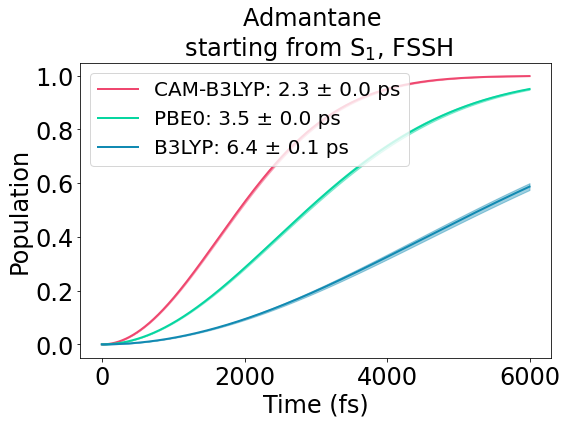

In [4]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from libra_py import units

def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level=0.95, r2_min=0.7):
    # 创建画布
    fig, ax = plt.subplots(figsize=(8, 6))

    # 指定颜色代码
    colors = ['#EF476F', '#06D6A0', '#118AB2']  # 红、绿、蓝
    prefixes = ["FSSH1_icond_", "FSSH0_icond_", "FSSH_icond_"]  # 三种路径格式
    pre_name = ["CAM-B3LYP", "PBE0", "B3LYP"]  # 三种路径对应名称
    for method in methods:
        for i, prefix in enumerate(prefixes):
            taus = []
            fit_function = fitting_for_method[method]

            for icond in iconds:
                filepath = f"{prefix}{icond}/mem_data.hdf"
                try:
                    # 读取数据
                    with h5py.File(filepath, 'r') as F:
                        sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                        md_time = np.array(F['time/data'][:]) * units.au2fs
                except FileNotFoundError:
                    print(f"File not found: {filepath}, skipping.")
                    continue

                # 数据拟合
                popt, _ = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
                residuals = sh_pop - fit_function(md_time, *popt)
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
                r_squared = 1.0 - (ss_res / ss_tot)

                # 筛选符合R^2阈值的数据
                if r_squared > r2_min:
                    taus.append(popt)
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, tau: {popt}")
                else:
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, skipped.")

            # 统计结果并绘制拟合曲线
            if taus:
                taus = np.array(taus)
                ave_tau = np.mean(taus)
                s = np.std(taus)
                N = taus.shape[0]
                Z = stdtrit(N - 1, conf_level)
                error_bar = Z * s / np.sqrt(N)

                # 时间尺度转换为皮秒
                ave_tau_ps = ave_tau / 1000
                error_bar_ps = error_bar / 1000
                print(f'{method} ({prefix}): {ave_tau_ps:.2f} ± {error_bar_ps:.2f} ps (N={N})')

                # 绘制拟合曲线（加粗线条）
                ax.plot(md_time, fit_function(md_time, ave_tau), color=colors[i], label=f"{pre_name[i]}: {ave_tau_ps:.1f} ± {error_bar_ps:.1f} ps", linewidth=2)  # 加粗线条
                # 绘制误差条（加深透明度和加粗）
                ax.fill_between(md_time, 
                                fit_function(md_time, ave_tau - error_bar), 
                                fit_function(md_time, ave_tau + error_bar), 
                                color=colors[i], alpha=0.4)  # 提高透明度

    # 图表设置
    ax.set_title(figuretitle, fontsize=24)
    ax.set_xlabel('Time (fs)', fontsize=24)
    ax.set_ylabel('Population', fontsize=24)
    ax.tick_params(axis='both', labelsize=24)
    ax.legend(fontsize=20)
    plt.tight_layout()
    plt.savefig(figurename, dpi=300)
    plt.show()

# 定义拟合函数
def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

# 参数设置与调用
methods = ["FSSH"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'FSSH': gau_func}
figuretitle = "Admantane \n starting from S$_1$, FSSH"
figurename = "FSSH_combined_fit.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level=0.95, r2_min=0.8)


Path: 00000GFSH_icond_, icond: 1, r_squared: 0.974827252849452, tau: [65516.10293939]
Path: 00000GFSH_icond_, icond: 101, r_squared: 0.9631562681658478, tau: [86629.60545669]
Path: 00000GFSH_icond_, icond: 201, r_squared: 0.9403442535620751, tau: [71876.69542594]
Path: 00000GFSH_icond_, icond: 301, r_squared: 0.9658317660102418, tau: [86976.75096716]
Path: 00000GFSH_icond_, icond: 401, r_squared: 0.9715108356272548, tau: [52812.16082765]
Path: 00000GFSH_icond_, icond: 501, r_squared: 0.981410485824636, tau: [56673.17174817]
Path: 00000GFSH_icond_, icond: 601, r_squared: 0.9677019052025423, tau: [62804.13682645]
Path: 00000GFSH_icond_, icond: 701, r_squared: 0.9650293183144628, tau: [59192.15772034]
Path: 00000GFSH_icond_, icond: 801, r_squared: 0.9670681788440483, tau: [65620.59729692]
Path: 00000GFSH_icond_, icond: 901, r_squared: 0.9673475298334526, tau: [59324.94588008]
GFSH (00000GFSH_icond_): 66.74 ± 6.50 ps (N=10)
Path: 11111GFSH_icond_, icond: 1, r_squared: 0.8428895142427129, t

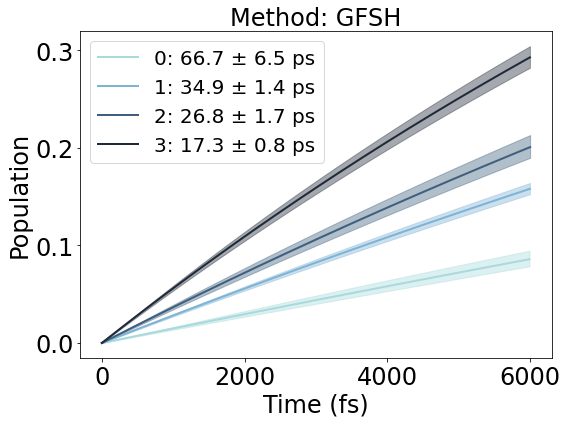

In [3]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from libra_py import units

def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level=0.95, r2_min=0.7):
    # 创建画布
    fig, ax = plt.subplots(figsize=(8, 6))

    fig.patch.set_facecolor('white')  # 设置图像背景为白色
    ax.set_facecolor('white')        # 设置坐标轴背景为白色
    # 指定颜色代码
    colors = ['#A8DADC', '#7FB3D5', '#3E5F7D', '#1F2A38']
    prefixes = ["00000GFSH_icond_", "11111GFSH_icond_", "22222GFSH_icond_","33333GFSH_icond_"]  # 三种路径格式
    pre_name = ["0", "1", "2",'3']  # 三种路径对应名称
    for method in methods:
        for i, prefix in enumerate(prefixes):
            taus = []
            fit_function = fitting_for_method[method]

            for icond in iconds:
                filepath = f"{prefix}{icond}/mem_data.hdf"
                try:
                    # 读取数据
                    with h5py.File(filepath, 'r') as F:
                        sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                        md_time = np.array(F['time/data'][:]) * units.au2fs
                except FileNotFoundError:
                    print(f"File not found: {filepath}, skipping.")
                    continue

                # 数据拟合
                popt, _ = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
                residuals = sh_pop - fit_function(md_time, *popt)
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
                r_squared = 1.0 - (ss_res / ss_tot)

                # 筛选符合R^2阈值的数据
                if r_squared > r2_min:
                    taus.append(popt)
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, tau: {popt}")
                else:
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, skipped.")

            # 统计结果并绘制拟合曲线
            if taus:
                taus = np.array(taus)
                ave_tau = np.mean(taus)
                s = np.std(taus)
                N = taus.shape[0]
                Z = stdtrit(N - 1, conf_level)
                error_bar = Z * s / np.sqrt(N)

                # 时间尺度转换为皮秒
                ave_tau_ps = ave_tau / 1000
                error_bar_ps = error_bar / 1000
                print(f'{method} ({prefix}): {ave_tau_ps:.2f} ± {error_bar_ps:.2f} ps (N={N})')

                # 绘制拟合曲线（加粗线条）
                ax.plot(md_time, fit_function(md_time, ave_tau), color=colors[i], label=f"{pre_name[i]}: {ave_tau_ps:.1f} ± {error_bar_ps:.1f} ps", linewidth=2)  # 加粗线条
                # 绘制误差条（加深透明度和加粗）
                ax.fill_between(md_time, 
                                fit_function(md_time, ave_tau - error_bar), 
                                fit_function(md_time, ave_tau + error_bar), 
                                color=colors[i], alpha=0.4)  # 提高透明度

    # 图表设置
    ax.set_title(figuretitle, fontsize=24)
    ax.set_xlabel('Time (fs)', fontsize=24)
    ax.set_ylabel('Population', fontsize=24)
    ax.tick_params(axis='both', labelsize=24)
    ax.legend(fontsize=20)
    plt.tight_layout()
    plt.savefig(figurename, dpi=600)
    plt.show()

# 定义拟合函数
def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

# 参数设置与调用
methods = ["GFSH"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'GFSH': exp_func}
figuretitle = "Method: GFSH"
figurename = "GFSH_combined_fit_reorder.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level=0.95, r2_min=0.8)


Path: IDA33_icond_, icond: 1, r_squared: 0.9741249435442741, tau: [866414.4889141]
Path: IDA33_icond_, icond: 101, r_squared: 0.9660425575190434, tau: [1068474.38997581]
Path: IDA33_icond_, icond: 201, r_squared: 0.9600486390260577, tau: [760764.92679055]
Path: IDA33_icond_, icond: 301, r_squared: 0.9682775641162852, tau: [623453.95103543]
Path: IDA33_icond_, icond: 401, r_squared: 0.9528496845832756, tau: [925463.76059081]
Path: IDA33_icond_, icond: 501, r_squared: 0.9476177688022834, tau: [725193.44145934]
Path: IDA33_icond_, icond: 601, r_squared: 0.9799778101660884, tau: [688425.12056306]
Path: IDA33_icond_, icond: 701, r_squared: 0.9743086255106036, tau: [515512.04720791]
Path: IDA33_icond_, icond: 801, r_squared: 0.9613034940540092, tau: [664491.1836866]
Path: IDA33_icond_, icond: 901, r_squared: 0.9391402054964652, tau: [864629.56310551]
IDA (IDA33_icond_): 770.28 ± 89.36 ps (N=10)
Path: IDAtttt_icond_, icond: 1, r_squared: 0.9029168620355543, tau: [831093.04957171]
Path: IDAttt

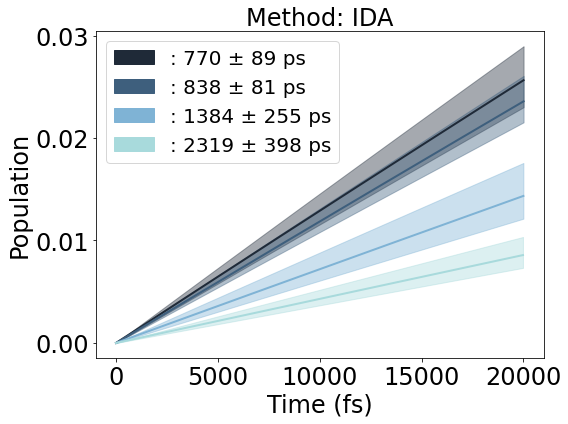

In [4]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # 用于生成矩形图例
from libra_py import units

def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level=0.95, r2_min=0.7):
    # 创建画布
    fig, ax = plt.subplots(figsize=(8, 6))

    fig.patch.set_facecolor('white')  # 设置图像背景为白色
    ax.set_facecolor('white')        # 设置坐标轴背景为白色
    # 指定颜色代码
    colors = ['#1F2A38', '#3E5F7D', '#7FB3D5' ,'#A8DADC']
    prefixes = ["IDA33_icond_", "IDAtttt_icond_", "IDA11_icond_", "IDA00_icond_"]  # 四种路径格式
    pre_name = ["", "", "", ""]  # 四种路径对应名称
    legend_patches = []  # 用于保存矩形图例

    for method in methods:
        for i, prefix in enumerate(prefixes):
            taus = []
            fit_function = fitting_for_method[method]

            for icond in iconds:
                filepath = f"{prefix}{icond}/mem_data.hdf"
                try:
                    # 读取数据
                    with h5py.File(filepath, 'r') as F:
                        sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                        md_time = np.array(F['time/data'][:]) * units.au2fs
                except FileNotFoundError:
                    print(f"File not found: {filepath}, skipping.")
                    continue

                # 数据拟合
                popt, _ = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
                residuals = sh_pop - fit_function(md_time, *popt)
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
                r_squared = 1.0 - (ss_res / ss_tot)

                # 筛选符合R^2阈值的数据
                if r_squared > r2_min:
                    taus.append(popt)
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, tau: {popt}")
                else:
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, skipped.")

            # 统计结果并绘制拟合曲线
            if taus:
                taus = np.array(taus)
                ave_tau = np.mean(taus)
                s = np.std(taus)
                N = taus.shape[0]
                Z = stdtrit(N - 1, conf_level)
                error_bar = Z * s / np.sqrt(N)

                # 时间尺度转换为皮秒
                ave_tau_ps = ave_tau / 1000
                error_bar_ps = error_bar / 1000
                print(f'{method} ({prefix}): {ave_tau_ps:.2f} ± {error_bar_ps:.2f} ps (N={N})')

                # 绘制拟合曲线（加粗线条）
                ax.plot(md_time, fit_function(md_time, ave_tau), color=colors[i], linewidth=2)
                # 绘制误差条（加深透明度和加粗）
                ax.fill_between(md_time, 
                                fit_function(md_time, ave_tau - error_bar), 
                                fit_function(md_time, ave_tau + error_bar), 
                                color=colors[i], alpha=0.4)

                # 添加图例矩形
                legend_patches.append(Patch(color=colors[i], label=f"{pre_name[i]}: {ave_tau_ps:.0f} ± {error_bar_ps:.0f} ps"))


    # 图表设置
    ax.set_title(figuretitle, fontsize=24)
    ax.set_xlabel('Time (fs)', fontsize=24)
    ax.set_ylabel('Population', fontsize=24)
    ax.tick_params(axis='both', labelsize=24)

    # 添加矩形图例
    ax.legend(handles=legend_patches, fontsize=20)

    plt.tight_layout()
    plt.savefig(figurename, dpi=600)
    plt.show()

# 定义拟合函数
def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

# 参数设置与调用
methods = ["IDA"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'IDA': exp_func}
figuretitle = "Method: IDA"
figurename = "IDAnew.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level=0.95, r2_min=0.8)



Path: IDA3_icond_, icond: 1, r_squared: 0.9657015273488663, tau: [913576.9165918]
Path: IDA3_icond_, icond: 101, r_squared: 0.9432470984746301, tau: [709477.94262421]
Path: IDA3_icond_, icond: 201, r_squared: 0.9719731369068627, tau: [782872.54400599]
Path: IDA3_icond_, icond: 301, r_squared: 0.9795306398188349, tau: [678247.33223546]
Path: IDA3_icond_, icond: 401, r_squared: 0.9528096179753218, tau: [543038.11730639]
Path: IDA3_icond_, icond: 501, r_squared: 0.9643485490207617, tau: [715612.14683593]
Path: IDA3_icond_, icond: 601, r_squared: 0.9744269049413264, tau: [781175.04022481]
Path: IDA3_icond_, icond: 701, r_squared: 0.9934305883703326, tau: [443611.97762021]
Path: IDA3_icond_, icond: 801, r_squared: 0.9772565618740536, tau: [580712.82230971]
Path: IDA3_icond_, icond: 901, r_squared: 0.9288767099068573, tau: [783492.93819954]
IDA (IDA3_icond_): 693 ± 75.8 ps (N=10)
Path: IDA2_icond_, icond: 1, r_squared: 0.955195848845259, tau: [666658.01447348]
Path: IDA2_icond_, icond: 101, 

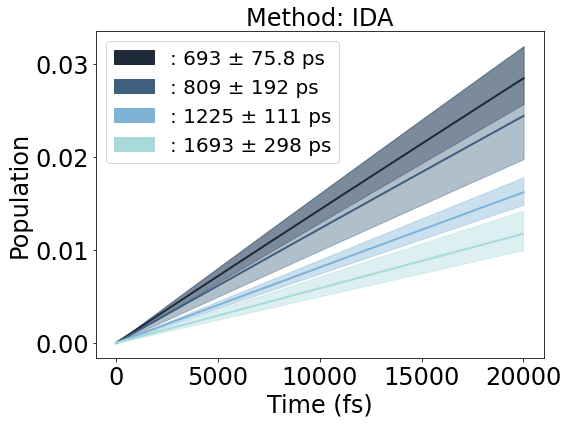

In [4]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # 用于生成矩形图例
from libra_py import units

def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level=0.95, r2_min=0.7):
    # 创建画布
    fig, ax = plt.subplots(figsize=(8, 6))

    fig.patch.set_facecolor('white')  # 设置图像背景为白色
    ax.set_facecolor('white')        # 设置坐标轴背景为白色
    # 指定颜色代码
    colors = ['#1F2A38', '#3E5F7D', '#7FB3D5' ,'#A8DADC']
    prefixes = ["IDA3_icond_", "IDA2_icond_", "IDA1_icond_", "IDA_icond_"]  # 四种路径格式
    pre_name = ["", "", "", ""]  # 四种路径对应名称
    legend_patches = []  # 用于保存矩形图例

    for method in methods:
        for i, prefix in enumerate(prefixes):
            taus = []
            fit_function = fitting_for_method[method]

            for icond in iconds:
                filepath = f"{prefix}{icond}/mem_data.hdf"
                try:
                    # 读取数据
                    with h5py.File(filepath, 'r') as F:
                        sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                        md_time = np.array(F['time/data'][:]) * units.au2fs
                except FileNotFoundError:
                    print(f"File not found: {filepath}, skipping.")
                    continue

                # 数据拟合
                popt, _ = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
                residuals = sh_pop - fit_function(md_time, *popt)
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
                r_squared = 1.0 - (ss_res / ss_tot)

                # 筛选符合R^2阈值的数据
                if r_squared > r2_min:
                    taus.append(popt)
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, tau: {popt}")
                else:
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, skipped.")

            # 统计结果并绘制拟合曲线
            if taus:
                taus = np.array(taus)
                ave_tau = np.mean(taus)
                s = np.std(taus)
                N = taus.shape[0]
                Z = stdtrit(N - 1, conf_level)
                error_bar = Z * s / np.sqrt(N)

                # 时间尺度转换为皮秒
                ave_tau_ps = ave_tau / 1000
                error_bar_ps = error_bar / 1000

                # 如果 ave_tau_ps 超过 100，去掉小数点
                if ave_tau_ps > 100:
                    ave_tau_ps_str = f"{int(ave_tau_ps)}"
                else:
                    ave_tau_ps_str = f"{ave_tau_ps:.1f}"

                # 如果 error_bar_ps 超过 100，去掉小数点
                if error_bar_ps > 100:
                    error_bar_ps_str = f"{int(error_bar_ps)}"
                else:
                    error_bar_ps_str = f"{error_bar_ps:.1f}"

                print(f'{method} ({prefix}): {ave_tau_ps_str} ± {error_bar_ps_str} ps (N={N})')

                # 绘制拟合曲线（加粗线条）
                ax.plot(md_time, fit_function(md_time, ave_tau), color=colors[i], linewidth=2)
                # 绘制误差条（加深透明度和加粗）
                ax.fill_between(md_time, 
                                fit_function(md_time, ave_tau - error_bar), 
                                fit_function(md_time, ave_tau + error_bar), 
                                color=colors[i], alpha=0.4)

                # 添加图例矩形
                legend_patches.append(Patch(color=colors[i], label=f"{pre_name[i]}: {ave_tau_ps_str} ± {error_bar_ps_str} ps"))

    # 图表设置
    ax.set_title(figuretitle, fontsize=24)
    ax.set_xlabel('Time (fs)', fontsize=24)
    ax.set_ylabel('Population', fontsize=24)
    ax.tick_params(axis='both', labelsize=24)

    # 添加矩形图例
    ax.legend(handles=legend_patches, fontsize=20)

    plt.tight_layout()
    plt.savefig(figurename, dpi=600)
    plt.show()

# 定义拟合函数
def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

# 参数设置与调用
methods = ["IDA"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'IDA': exp_func}
figuretitle = "Method: IDA"
figurename = "IDA.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level=0.95, r2_min=0.8)


File not found: IDA3_icond_1/mem_data.hdf, skipping.
File not found: IDA3_icond_101/mem_data.hdf, skipping.
File not found: IDA3_icond_201/mem_data.hdf, skipping.
File not found: IDA3_icond_301/mem_data.hdf, skipping.
File not found: IDA3_icond_401/mem_data.hdf, skipping.
File not found: IDA3_icond_501/mem_data.hdf, skipping.
File not found: IDA3_icond_601/mem_data.hdf, skipping.
File not found: IDA3_icond_701/mem_data.hdf, skipping.
File not found: IDA3_icond_801/mem_data.hdf, skipping.
File not found: IDA3_icond_901/mem_data.hdf, skipping.
File not found: IDA2_icond_1/mem_data.hdf, skipping.
File not found: IDA2_icond_101/mem_data.hdf, skipping.
File not found: IDA2_icond_201/mem_data.hdf, skipping.
File not found: IDA2_icond_301/mem_data.hdf, skipping.
File not found: IDA2_icond_401/mem_data.hdf, skipping.
File not found: IDA2_icond_501/mem_data.hdf, skipping.
File not found: IDA2_icond_601/mem_data.hdf, skipping.
File not found: IDA2_icond_701/mem_data.hdf, skipping.
File not found

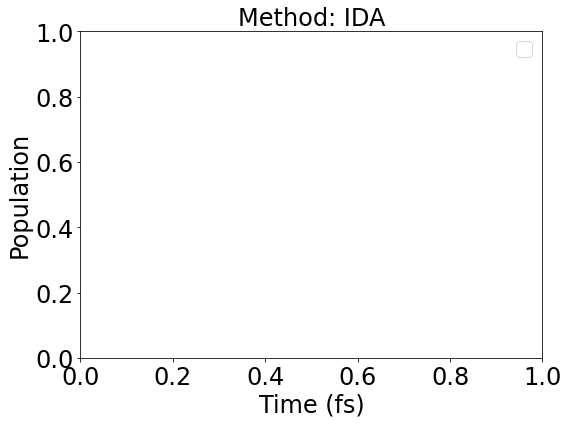

In [3]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # 用于生成矩形图例
from libra_py import units

def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level=0.95, r2_min=0.7):
    # 创建画布
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor('white')  # 图像背景白色
    ax.set_facecolor('white')         # 坐标轴背景白色

    # 指定颜色代码
    colors = ['#1F2A38', '#3E5F7D', '#7FB3D5' ,'#A8DADC']
    prefixes = ["IDA3_icond_", "IDA2_icond_", "IDA1_icond_", "IDA_icond_"]  # 四种路径格式
    pre_name = ["", "", "", ""]  # 可根据需要设置标签前缀
    legend_patches = []

    for method in methods:
        for i, prefix in enumerate(prefixes):
            taus = []
            fit_function = fitting_for_method[method]

            for icond in iconds:
                filepath = f"{prefix}{icond}/mem_data.hdf"
                try:
                    with h5py.File(filepath, 'r') as F:
                        sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                        md_time = np.array(F['time/data'][:]) * units.au2fs
                except FileNotFoundError:
                    print(f"File not found: {filepath}, skipping.")
                    continue

                # 数据拟合
                try:
                    popt, _ = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
                except RuntimeError:
                    print(f"Fit failed: {filepath}, skipping.")
                    continue

                residuals = sh_pop - fit_function(md_time, *popt)
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
                r_squared = 1.0 - (ss_res / ss_tot)

                if r_squared > r2_min:
                    taus.append(popt)
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared:.3f}, tau: {popt}")
                else:
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared:.3f}, skipped.")

            if taus:
                taus = np.array(taus)
                ave_tau = np.mean(taus)
                s = np.std(taus)
                N = taus.shape[0]
                Z = stdtrit(N - 1, conf_level)
                error_bar = Z * s / np.sqrt(N)

                # 转换为皮秒
                ave_tau_ps = ave_tau / 1000
                error_bar_ps = error_bar / 1000
                print(f'{method} ({prefix}): {ave_tau_ps:.2f} ± {error_bar_ps:.2f} ps (N={N})')

                # 绘制拟合曲线
                ax.plot(md_time, fit_function(md_time, ave_tau), color=colors[i], linewidth=2)
                ax.fill_between(md_time,
                                fit_function(md_time, ave_tau - error_bar),
                                fit_function(md_time, ave_tau + error_bar),
                                color=colors[i], alpha=0.4)

                # 图例（整数形式）
                legend_label = f"{pre_name[i]}: {int(round(ave_tau_ps))} ± {int(round(error_bar_ps))} ps"
                legend_patches.append(Patch(color=colors[i], label=legend_label))

    # 图表设置
    ax.set_title(figuretitle, fontsize=24)
    ax.set_xlabel('Time (fs)', fontsize=24)
    ax.set_ylabel('Population', fontsize=24)
    ax.tick_params(axis='both', labelsize=24)
    ax.legend(handles=legend_patches, fontsize=20)

    plt.tight_layout()
    plt.savefig(figurename, dpi=600)
    plt.show()

# 拟合函数
def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

# 参数设置与调用
methods = ["IDA"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'IDA': exp_func}
figuretitle = "Method: IDA"
figurename = "IDA.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level=0.95, r2_min=0.8)

Path: FSSH1_icond_, icond: 1, r_squared: 0.998584500056666, tau: [2341.80059885]
Path: FSSH1_icond_, icond: 101, r_squared: 0.9987706360934188, tau: [2236.30279234]
Path: FSSH1_icond_, icond: 201, r_squared: 0.999009409124415, tau: [2317.17054351]
Path: FSSH1_icond_, icond: 301, r_squared: 0.9972553127305266, tau: [2293.84540977]
Path: FSSH1_icond_, icond: 401, r_squared: 0.9977590632080098, tau: [2338.24448185]
Path: FSSH1_icond_, icond: 501, r_squared: 0.9976869235017465, tau: [2294.68742452]
Path: FSSH1_icond_, icond: 601, r_squared: 0.9976665978430597, tau: [2324.85867325]
Path: FSSH1_icond_, icond: 701, r_squared: 0.998178679736453, tau: [2347.48746381]
Path: FSSH1_icond_, icond: 801, r_squared: 0.9988318240622659, tau: [2254.98391344]
Path: FSSH1_icond_, icond: 901, r_squared: 0.9963118971584426, tau: [2286.78047677]
FSSH (FSSH1_icond_): 2.30 ± 0.02 ps (N=10)
Path: FSSH0_icond_, icond: 1, r_squared: 0.992184566448746, tau: [3474.80122405]
Path: FSSH0_icond_, icond: 101, r_squared

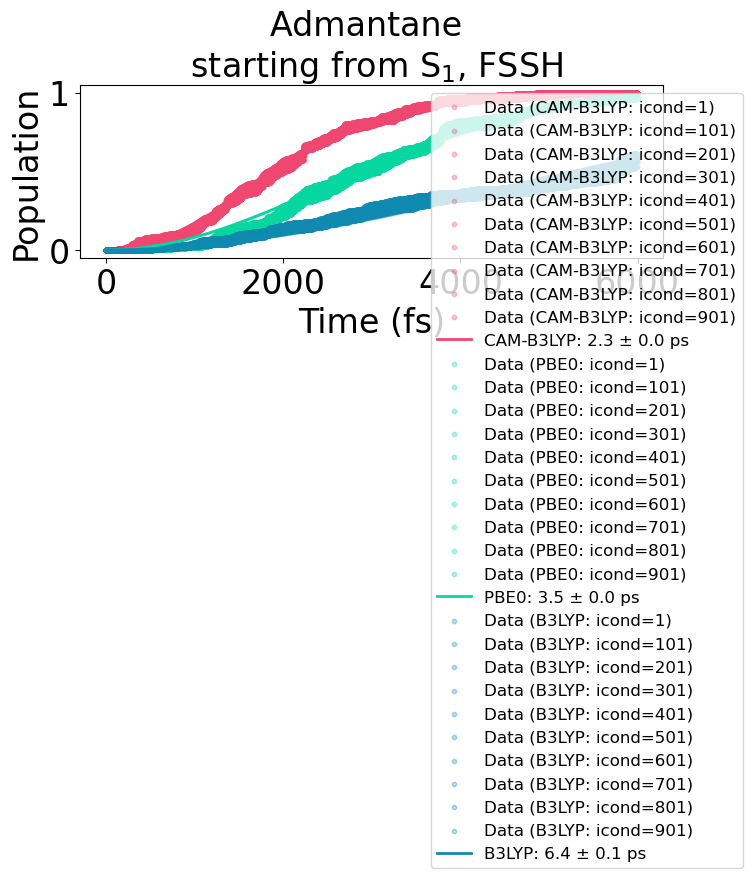

In [9]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from libra_py import units

def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level=0.95, r2_min=0.7):
    # 创建画布
    fig, ax = plt.subplots(figsize=(8, 6))

    fig.patch.set_facecolor('white')  # 设置图像背景为白色
    ax.set_facecolor('white')        # 设置坐标轴背景为白色
    # 指定颜色代码
    colors = ['#EF476F', '#06D6A0', '#118AB2']  # 红、绿、蓝
    prefixes = ["FSSH1_icond_", "FSSH0_icond_", "FSSH_icond_"]  # 三种路径格式
    pre_name = ["CAM-B3LYP", "PBE0", "B3LYP"]  # 三种路径对应名称
    for method in methods:
        for i, prefix in enumerate(prefixes):
            taus = []
            fit_function = fitting_for_method[method]

            for icond in iconds:
                filepath = f"{prefix}{icond}/mem_data.hdf"
                try:
                    # 读取数据
                    with h5py.File(filepath, 'r') as F:
                        sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                        md_time = np.array(F['time/data'][:]) * units.au2fs
                except FileNotFoundError:
                    print(f"File not found: {filepath}, skipping.")
                    continue

                # 绘制原始数据点
                ax.scatter(md_time, sh_pop, color=colors[i], alpha=0.3, label=f"Data ({pre_name[i]}: icond={icond})", s=10)

                # 数据拟合
                popt, _ = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
                residuals = sh_pop - fit_function(md_time, *popt)
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
                r_squared = 1.0 - (ss_res / ss_tot)

                # 筛选符合R^2阈值的数据
                if r_squared > r2_min:
                    taus.append(popt)
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, tau: {popt}")
                else:
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, skipped.")

            # 统计结果并绘制拟合曲线
            if taus:
                taus = np.array(taus)
                ave_tau = np.mean(taus)
                s = np.std(taus)
                N = taus.shape[0]
                Z = stdtrit(N - 1, conf_level)
                error_bar = Z * s / np.sqrt(N)

                # 时间尺度转换为皮秒
                ave_tau_ps = ave_tau / 1000
                error_bar_ps = error_bar / 1000
                print(f'{method} ({prefix}): {ave_tau_ps:.2f} ± {error_bar_ps:.2f} ps (N={N})')

                # 绘制拟合曲线（加粗线条）
                ax.plot(md_time, fit_function(md_time, ave_tau), color=colors[i], label=f"{pre_name[i]}: {ave_tau_ps:.1f} ± {error_bar_ps:.1f} ps", linewidth=2)  # 加粗线条
                # 绘制误差条（加深透明度和加粗）
                ax.fill_between(md_time, 
                                fit_function(md_time, ave_tau - error_bar), 
                                fit_function(md_time, ave_tau + error_bar), 
                                color=colors[i], alpha=0.4)  # 提高透明度

    # 图表设置
    ax.set_title(figuretitle, fontsize=24)
    ax.set_xlabel('Time (fs)', fontsize=24)
    ax.set_ylabel('Population', fontsize=24)
    ax.tick_params(axis='both', labelsize=24)
    ax.legend(fontsize=12, loc='upper right', bbox_to_anchor=(1.15, 1))  # 调整图例位置
    plt.tight_layout()
    plt.savefig(figurename, dpi=300)
    plt.show()

# 定义拟合函数
def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

# 参数设置与调用
methods = ["FSSH"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'FSSH': gau_func}
figuretitle = "Admantane \n starting from S$_1$, FSSH"
figurename = "FSSH_combined_fit_reorder.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level=0.95, r2_min=0.8)


Path: FSSH1_icond_, icond: 1, r_squared: 0.998584500056666, tau: [2341.80059885]
Path: FSSH1_icond_, icond: 101, r_squared: 0.9987706360934188, tau: [2236.30279234]
Path: FSSH1_icond_, icond: 201, r_squared: 0.999009409124415, tau: [2317.17054351]
Path: FSSH1_icond_, icond: 301, r_squared: 0.9972553127305266, tau: [2293.84540977]
Path: FSSH1_icond_, icond: 401, r_squared: 0.9977590632080098, tau: [2338.24448185]
Path: FSSH1_icond_, icond: 501, r_squared: 0.9976869235017465, tau: [2294.68742452]
Path: FSSH1_icond_, icond: 601, r_squared: 0.9976665978430597, tau: [2324.85867325]
Path: FSSH1_icond_, icond: 701, r_squared: 0.998178679736453, tau: [2347.48746381]
Path: FSSH1_icond_, icond: 801, r_squared: 0.9988318240622659, tau: [2254.98391344]
Path: FSSH1_icond_, icond: 901, r_squared: 0.9963118971584426, tau: [2286.78047677]
FSSH (FSSH1_icond_): 2.30 ± 0.02 ps (N=10)
Path: FSSH0_icond_, icond: 1, r_squared: 0.992184566448746, tau: [3474.80122405]
Path: FSSH0_icond_, icond: 101, r_squared

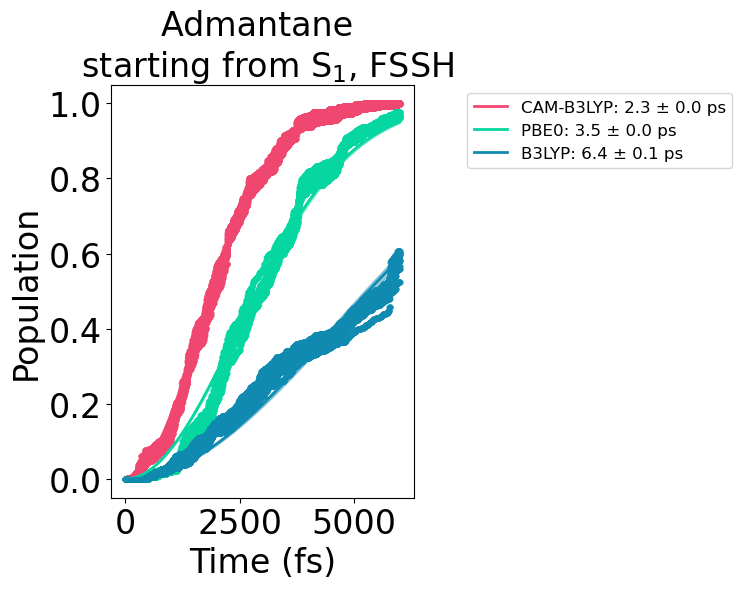

In [11]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from libra_py import units

def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level=0.95, r2_min=0.7):
    # 创建画布
    fig, ax = plt.subplots(figsize=(8, 6))

    fig.patch.set_facecolor('white')  # 设置图像背景为白色
    ax.set_facecolor('white')        # 设置坐标轴背景为白色
    # 指定颜色代码
    colors = ['#EF476F', '#06D6A0', '#118AB2']  # 红、绿、蓝
    prefixes = ["FSSH1_icond_", "FSSH0_icond_", "FSSH_icond_"]  # 三种路径格式
    pre_name = ["CAM-B3LYP", "PBE0", "B3LYP"]  # 三种路径对应名称
    for method in methods:
        for i, prefix in enumerate(prefixes):
            taus = []
            fit_function = fitting_for_method[method]

            for icond in iconds:
                filepath = f"{prefix}{icond}/mem_data.hdf"
                try:
                    # 读取数据
                    with h5py.File(filepath, 'r') as F:
                        sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                        md_time = np.array(F['time/data'][:]) * units.au2fs
                except FileNotFoundError:
                    print(f"File not found: {filepath}, skipping.")
                    continue

                # 绘制原始数据点
                ax.scatter(md_time, sh_pop, color=colors[i], alpha=0.3, s=10, label="_nolegend_")

                # 数据拟合
                popt, _ = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
                residuals = sh_pop - fit_function(md_time, *popt)
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
                r_squared = 1.0 - (ss_res / ss_tot)

                # 筛选符合R^2阈值的数据
                if r_squared > r2_min:
                    taus.append(popt)
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, tau: {popt}")
                else:
                    print(f"Path: {prefix}, icond: {icond}, r_squared: {r_squared}, skipped.")

            # 统计结果并绘制拟合曲线
            if taus:
                taus = np.array(taus)
                ave_tau = np.mean(taus)
                s = np.std(taus)
                N = taus.shape[0]
                Z = stdtrit(N - 1, conf_level)
                error_bar = Z * s / np.sqrt(N)

                # 时间尺度转换为皮秒
                ave_tau_ps = ave_tau / 1000
                error_bar_ps = error_bar / 1000
                print(f'{method} ({prefix}): {ave_tau_ps:.2f} ± {error_bar_ps:.2f} ps (N={N})')

                # 绘制拟合曲线（加粗线条）
                ax.plot(md_time, fit_function(md_time, ave_tau), color=colors[i], label=f"{pre_name[i]}: {ave_tau_ps:.1f} ± {error_bar_ps:.1f} ps", linewidth=2)  # 加粗线条
                # 绘制误差条（加深透明度和加粗）
                ax.fill_between(md_time, 
                                fit_function(md_time, ave_tau - error_bar), 
                                fit_function(md_time, ave_tau + error_bar), 
                                color=colors[i], alpha=0.4)  # 提高透明度

    # 图表设置
    ax.set_title(figuretitle, fontsize=24)
    ax.set_xlabel('Time (fs)', fontsize=24)
    ax.set_ylabel('Population', fontsize=24)
    ax.tick_params(axis='both', labelsize=24)
    ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.15, 1))  # 调整图例位置
    plt.tight_layout()
    plt.savefig(figurename, dpi=300)
    plt.show()

# 定义拟合函数
def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

# 参数设置与调用
methods = ["FSSH"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'FSSH': gau_func}
figuretitle = "Admantane \n starting from S$_1$, FSSH"
figurename = "FSSH_combined_fit_reorder.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level=0.95, r2_min=0.8)


In [1]:
###=====================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scipy.sparse as sp
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
from scipy.constants import physical_constants
from libra_py import trpes
import os

# ========== 全局参数 ==========
iconds = list(range(1, 1000, 100))  # ICONDS: 1,101,201,...
method = "FSSH2"
color = "black"

au2ev = physical_constants["hartree-electron volt relationship"][0]
au2fs = physical_constants["atomic unit of time"][0] * 1e15

FIGSIZE = (16, 12)   # 左右两列大图
font_size = 40
tick_font = 32

# ========== TRPES 计算 ==========
x = {
    "istep": 6100,
    "fstep": 9100,
    "dt": 1.0,
    "namd_nsteps": 3000,
    "units": "eV",
    "eprefix": "/vscratch/grp-alexeyak/qingxin/2_methy_300K_11_25/step2_B3LYP/all_logfiles/step_",
    "esuffix": ".log",
    "input_file_type": 1,
    "logfile_read_params": {"number_of_states": 30},
    "iconds": iconds,
    "dprefix": "/vscratch/grp-alexeyak/qingxin/2_methy_300K_11_25/step4/S1_FSSH2_test/FSSH20_icond_",
    "dsuffix": "/mem_data.hdf",
    "de": 0.1,
    "emin": 0.0,
    "emax": 10.0,
    "sigma_e": 0.6,
}

time_bins, energy_grid, H_total = trpes.compute_trpes(x)

# ========== 拟合函数（高斯型弛豫）==========
def refined_func(t, tau, E0, E1):
    return (E0 - E1) * np.exp(-(t / tau) ** 2) + E1

# ========== 读取绝热能量（Hvib 对角元）==========
energies = []
Hvib_path = "/vscratch/grp-alexeyak/qingxin/2_methy_300K_11_25/step33_nthree_B3LYP"
for step in range(6100, 9100):
    hv_file = f"{Hvib_path}/Hvib_ci_{step}_re.npz"
    hvib = sp.load_npz(hv_file).todense().real
    energies.append(np.diag(hvib))

energies = np.array(energies)   # (nsteps, nstates)
energies = au2ev * energies
adiabatic_energies = energies
e2 = energies

# ========== 计算每条轨迹的 excess energy 并拟合 tau ==========
all_excess_energies = []
taus = []
time_ref = None

for icond in iconds:
    h5_path = f"/vscratch/grp-alexeyak/qingxin/2_methy_300K_11_25/step4/S1_FSSH2_test/{method}0_icond_{icond}/mem_data.hdf"
    try:
        with h5py.File(h5_path, "r") as F:
            sh_pop = np.array(F["sh_pop_adi/data"])          # (nsteps, nstates)
            time = np.array(F["time/data"])[0:3000] * au2fs  # fs

        if time_ref is None:
            time_ref = time

        tmp2 = np.roll(e2[0:3000, :], -icond, axis=0)
        tmp1 = sh_pop[0:3000, :] * tmp2
        tmp = np.sum(tmp1, axis=1)

        all_excess_energies.append(tmp)

        E0 = tmp[0]
        E1 = adiabatic_energies[:, 1].mean()

        popt, _ = curve_fit(
            lambda t, tau: refined_func(t, tau, E0, E1),
            time,
            tmp,
            maxfev=10000,
        )
        taus.append(popt[0])

    except Exception as e:
        print(f"[WARN] icond {icond} 出错: {e}")

if len(all_excess_energies) == 0:
    raise RuntimeError("没有成功读取到任何轨迹的 excess energy，请检查路径和文件。")

avg_excess_energy = np.mean(all_excess_energies, axis=0)

# ========== 构建“去蓝紫”的彩虹色图 ==========
base_cmap = plt.cm.get_cmap("coolwarm")
colors = base_cmap(np.linspace(0.0, 1.0, 256))
cmap_no_blue_purple = ListedColormap(colors)

# ========== 右边要用的 DOS + UV-VIS 数据 ==========
energy_levels = []
for step in range(6100, 9100):
    file_path = f"{Hvib_path}/Hvib_ci_{step}_re.npz"
    if os.path.exists(file_path):
        Hvib = sp.load_npz(file_path).todense().real
        diag_energies = np.diag(Hvib) * au2ev
        energy_levels.extend(diag_energies)

energy_levels = np.array(energy_levels)

uvvis_path = "2.txt"
x_spec, y_spec = [], []
with open(uvvis_path, "r") as f:
    for line in f:
        if line.strip():
            parts = line.split()
            x_spec.append(float(parts[0]))
            y_spec.append(float(parts[1]))

x_spec = np.array(x_spec)
y_spec = np.array(y_spec)

# ========== 画在同一张 figure 上：左右两列，sharey 硬锁 y 轴 ==========
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=FIGSIZE,
    sharey=True,
    gridspec_kw={"wspace": 0.15}
)

# ---------- 左：TRPES ----------
extent = [time_bins[0], time_bins[-1], energy_grid[0], energy_grid[-1]]

im = ax1.imshow(
    H_total.T,
    extent=extent,
    origin="lower",
    aspect="auto",
    cmap=cmap_no_blue_purple,
)

ax1.plot(
    time_ref[:len(avg_excess_energy)],
    avg_excess_energy,
    color=color,
    linewidth=3,
)

ax1.set_xlim(0, 3000)
ax1.set_xticks(np.arange(0, 3001, 1000))

ax1.set_ylim(0, 10)
ax1.set_ylabel("Energy (eV)", fontsize=font_size)

ax1.tick_params(axis="x", labelsize=tick_font, pad=15)
ax1.tick_params(axis="y", labelsize=tick_font, pad=15)

# 给左图加 colorbar（只占左 panel）
cbar = fig.colorbar(im, ax=ax1, pad=0.02)
cbar.set_label("Population", fontsize=font_size, labelpad=15)
cbar.ax.tick_params(labelsize=tick_font)

# ---------- 右：DOS + UV-VIS ----------
hist_values, bins, _ = ax2.hist(
    energy_levels,
    bins=50,
    density=True,
    orientation="horizontal",
    color="gray",
    edgecolor="black",
    alpha=0.7,
)

max_hist_value = hist_values.max()
scaling_factor = max_hist_value / max(y_spec)
y_norm = y_spec * scaling_factor

ax2.plot(
    y_norm,
    x_spec,
    linestyle="-",
    color="red",
    linewidth=3,
    label="UV-VIS",
)

ax2.set_ylim(0, 10)
ax2.tick_params(axis="y", which="both", left=False, labelleft=False)
ax2.tick_params(axis="x", labelsize=tick_font, pad=15)
ax2.legend(fontsize=28, loc="upper right")

# ========== 先统一整体边距 ==========
fig.subplots_adjust(left=0.10, right=0.95, bottom=0.12, top=0.96)

# ========== 再单独把右图轻微右移一点 ==========
pos = ax2.get_position()
# 可以微调 shift 和 width_factor 的数值
shift = 0.03          # 往右移一点点
width_factor = 0.97    # 稍微变瘦一点，避免碰到右边界
new_x0 = pos.x0 + shift
new_width = pos.width * width_factor
ax2.set_position([new_x0, pos.y0, new_width, pos.height])

fig.savefig("TRPES_DOS_UVVIS_2methy_combinedcoolwarmttt.png",  facecolor='white',dpi=300)
plt.show()

{'istep': 6100, 'fstep': 9100, 'dt': 1.0, 'namd_nsteps': 3000, 'units': 'eV', 'eprefix': '/vscratch/grp-alexeyak/qingxin/2_methy_300K_11_25/step2_B3LYP/all_logfiles/step_', 'esuffix': '.log', 'input_file_type': 1, 'logfile_read_params': {'number_of_states': 30}, 'iconds': [1, 101, 201, 301, 401, 501, 601, 701, 801, 901], 'dprefix': '/vscratch/grp-alexeyak/qingxin/2_methy_300K_11_25/step4/S1_FSSH2_test/FSSH20_icond_', 'dsuffix': '/mem_data.hdf', 'de': 0.1, 'emin': 0.0, 'emax': 10.0, 'sigma_e': 0.6}
Trajectory data contains 3000, while we only want 3000
The TRPES plot will be of the time legnth of 3000 points
The multiplication factor is 1
The shape of the effective E array is (3000, 31)
Initial iconds = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901]
Renormalizing iconds for istep = 6100, fstep = 9100 and nsteps = 3000...
The effective iconds are = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901] (dropping off meaningless iconds)
Reading the file /vscratch/grp-alexeyak/qingxin/2_methy_